In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (12,6)

print("EDA Notebook Ready")

EDA Notebook Ready


In [2]:
# Load processed dataset
df = pd.read_csv("../data/processed/economic_data.csv")

# Convert DATE column
df["DATE"] = pd.to_datetime(df["DATE"])

print(df.shape)
df.head()

(2061, 11)


,DATE,Consumer_Sentiment,CPI,Federal_Funds_Rate,Housing_Starts,Industrial_Production,Real_GDP,Recession,Treasury_10Y,Treasury_2Y,Unemployment
0,1854-12-01,86.2,21.48,0.8,1657.0,4.8739,2182.681,1.0,2.83,7.06,3.4
1,1855-01-01,86.2,21.48,0.8,1657.0,4.8739,2182.681,0.0,2.83,7.06,3.4
2,1855-02-01,86.2,21.48,0.8,1657.0,4.8739,2182.681,0.0,2.83,7.06,3.4
3,1855-03-01,86.2,21.48,0.8,1657.0,4.8739,2182.681,0.0,2.83,7.06,3.4
4,1855-04-01,86.2,21.48,0.8,1657.0,4.8739,2182.681,0.0,2.83,7.06,3.4


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2061 entries, 0 to 2060
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   DATE                   2061 non-null   datetime64[us]
 1   Consumer_Sentiment     2061 non-null   float64       
 2   CPI                    2061 non-null   float64       
 3   Federal_Funds_Rate     2061 non-null   float64       
 4   Housing_Starts         2061 non-null   float64       
 5   Industrial_Production  2061 non-null   float64       
 6   Real_GDP               2061 non-null   float64       
 7   Recession              2061 non-null   float64       
 8   Treasury_10Y           2061 non-null   float64       
 9   Treasury_2Y            2061 non-null   float64       
 10  Unemployment           2061 non-null   float64       
dtypes: datetime64[us](1), float64(10)
memory usage: 177.2 KB


In [4]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
DATE,2061,1940-09-30 21:03:55.807861,1854-12-01 00:00:00,1897-11-01 00:00:00,1940-10-01 00:00:00,1983-09-01 00:00:00,2026-08-01 00:00:00,NaN
Consumer_Sentiment,2061.0,85.898302,44.8,86.2,86.2,86.2,112.0,8.591337
CPI,2061.0,69.866157,21.48,21.48,21.48,100.4,334.131,80.915422
Federal_Funds_Rate,2061.0,2.394537,0.05,0.8,0.8,3.48,19.1,2.955633
Housing_Starts,2061.0,1567.727802,478.0,1546.0,1657.0,1657.0,2494.0,260.278787
Industrial_Production,2061.0,31.316237,3.6891,4.8739,9.2361,52.0446,104.1004,34.600229
Real_GDP,2061.0,6012.854471,2172.432,2182.681,2182.681,7719.746,24269.613,6025.084045
Recession,2061.0,0.280932,0.0,0.0,0.0,1.0,1.0,0.449563
Treasury_10Y,2061.0,3.981033,0.62,2.83,2.83,4.25,15.32,2.298697
Treasury_2Y,2061.0,6.444736,0.12,7.06,7.06,7.06,16.46,2.195662


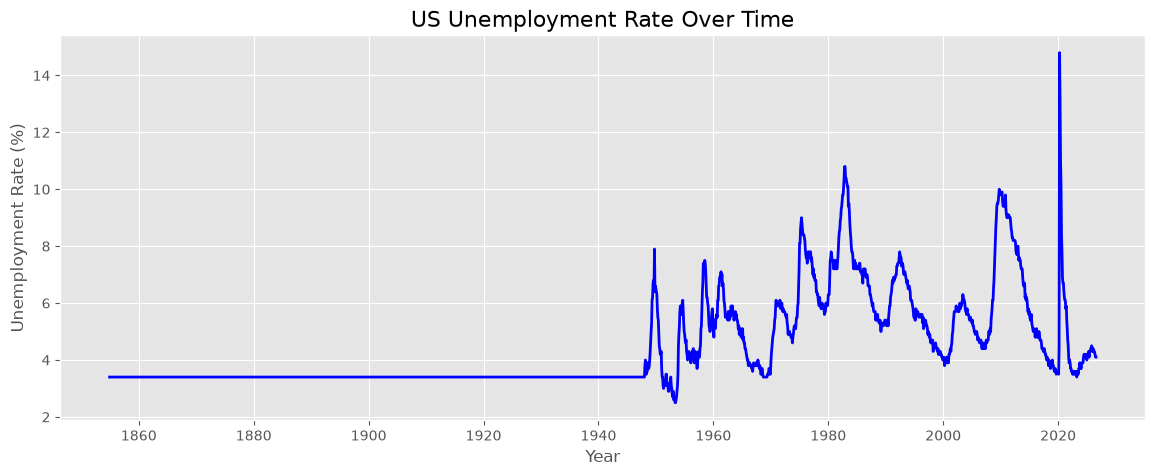

In [5]:
plt.figure(figsize=(14,5))

plt.plot(df["DATE"], df["Unemployment"], color="blue", linewidth=2)

plt.title("US Unemployment Rate Over Time", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Unemployment Rate (%)")

plt.show()

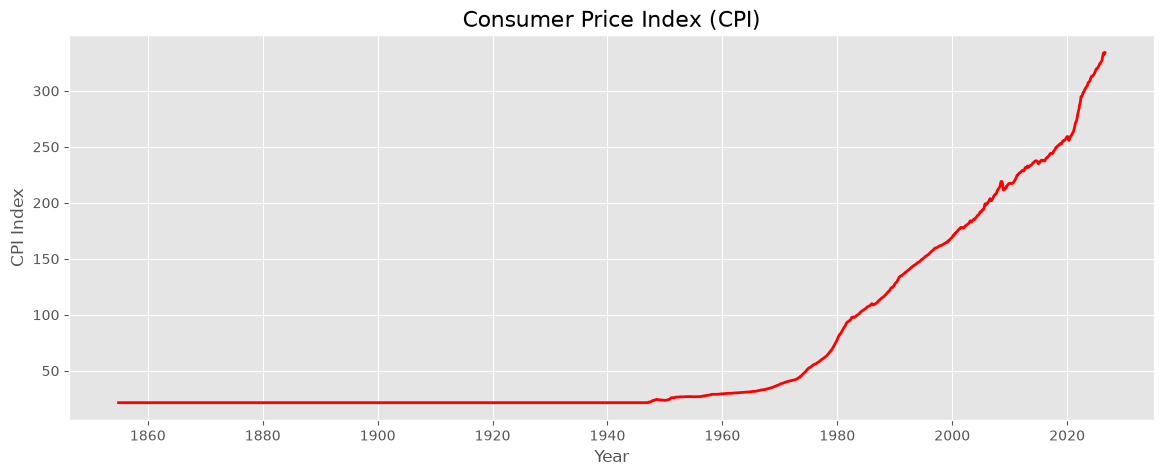

In [6]:
plt.figure(figsize=(14,5))

plt.plot(df["DATE"], df["CPI"], color="red", linewidth=2)

plt.title("Consumer Price Index (CPI)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("CPI Index")

plt.show()

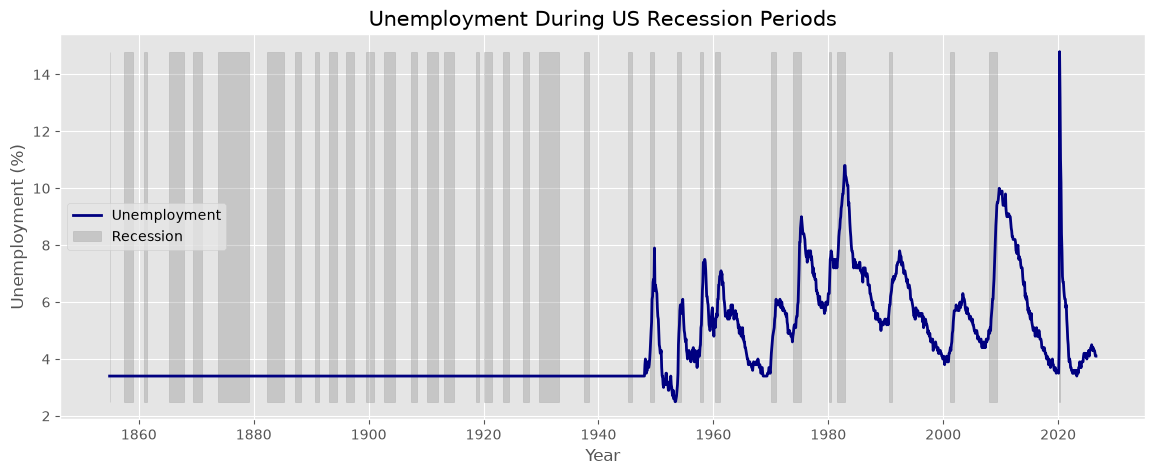

In [7]:
plt.figure(figsize=(14,5))

# Unemployment line
plt.plot(df["DATE"], df["Unemployment"],
         color="navy", linewidth=2, label="Unemployment")

# Shade recession periods
plt.fill_between(
    df["DATE"],
    df["Unemployment"].min(),
    df["Unemployment"].max(),
    where=df["Recession"]==1,
    color="gray",
    alpha=0.3,
    label="Recession"
)

plt.title("Unemployment During US Recession Periods", fontsize=15)
plt.xlabel("Year")
plt.ylabel("Unemployment (%)")
plt.legend()

plt.show()

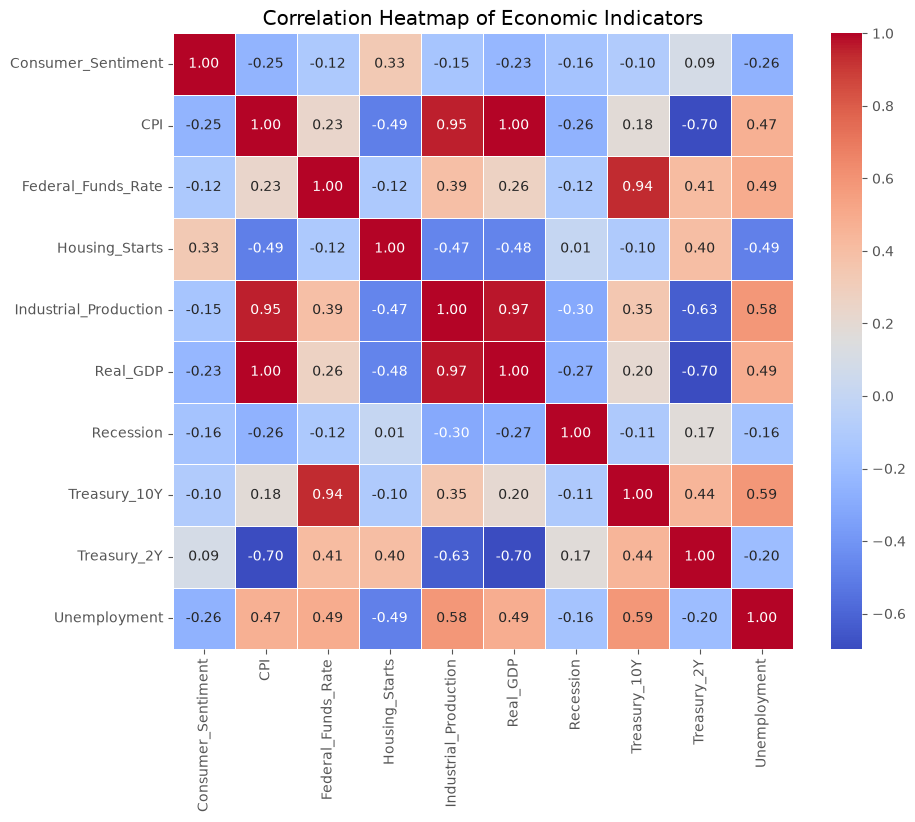

In [8]:
plt.figure(figsize=(10,8))

corr = df.drop(columns=["DATE"]).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Economic Indicators")
plt.show()

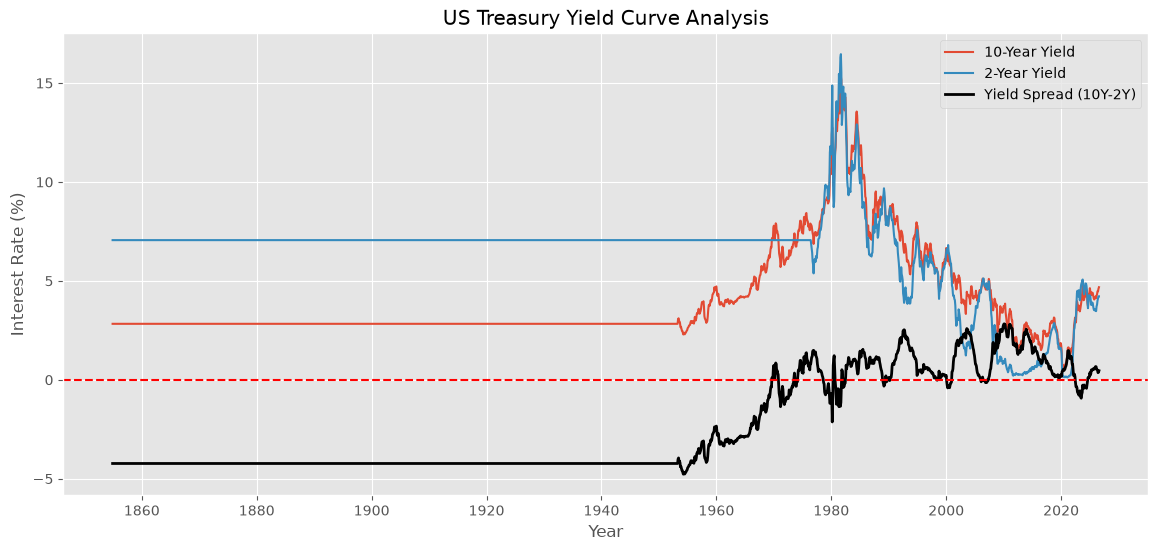

In [9]:
# Create Yield Spread
df["Yield_Spread"] = df["Treasury_10Y"] - df["Treasury_2Y"]

plt.figure(figsize=(14,6))

plt.plot(df["DATE"], df["Treasury_10Y"],
         label="10-Year Yield", linewidth=1.5)

plt.plot(df["DATE"], df["Treasury_2Y"],
         label="2-Year Yield", linewidth=1.5)

plt.plot(df["DATE"], df["Yield_Spread"],
         label="Yield Spread (10Y-2Y)",
         linewidth=2, color="black")

plt.axhline(0, linestyle="--", color="red")

plt.title("US Treasury Yield Curve Analysis")
plt.xlabel("Year")
plt.ylabel("Interest Rate (%)")
plt.legend()

plt.show()

In [10]:
stats = pd.DataFrame({
    "Mean": df.drop(columns=["DATE"]).mean(),
    "Median": df.drop(columns=["DATE"]).median(),
    "Std Dev": df.drop(columns=["DATE"]).std(),
    "Minimum": df.drop(columns=["DATE"]).min(),
    "Maximum": df.drop(columns=["DATE"]).max()
})

stats.round(2)

,Mean,Median,Std Dev,Minimum,Maximum
Consumer_Sentiment,85.90,86.20,8.59,44.80,112.00
CPI,69.87,21.48,80.92,21.48,334.13
Federal_Funds_Rate,2.39,0.80,2.96,0.05,19.10
Housing_Starts,1567.73,1657.00,260.28,478.00,2494.00
Industrial_Production,31.32,9.24,34.60,3.69,104.10
Real_GDP,6012.85,2182.68,6025.08,2172.43,24269.61
Recession,0.28,0.00,0.45,0.00,1.00
Treasury_10Y,3.98,2.83,2.30,0.62,15.32
Treasury_2Y,6.44,7.06,2.20,0.12,16.46
Unemployment,4.43,3.40,1.61,2.50,14.80
